In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import scipy.optimize as scippy
import scipy.stats as scist
from numpy.fft import fft, ifft
import os
import shutil
from numba import njit, prange
from scipy.integrate import quad
import pandas as pd

plt.rc("xtick", labelsize=20, top=True, direction="in")
plt.rc("ytick", labelsize=20, right=True, direction="in")
plt.rc("axes", titlesize=26)
plt.rc("axes", labelsize=26)
plt.rc("legend", fontsize=26)

# A

In [8]:
# Simulation parameters
N = 50

sigma = 1.0
L = 10.0*sigma
rho = N/(L**2) # 2D

kappa = 1.0
r_cut = 6.0 / kappa

gamma = 1.0 # gamma=xi from previously

kBT = 1.0
V_0 = 0.0
U_0 = V_0 / kBT

F_D = 0 * kBT / sigma

tau = gamma * sigma**2 / kBT # Time unit for everything
dt = 1e-4 * tau
t_equil = 10.0 * tau
t_prod = 10.0 * tau
# t_sim = t_equil + t_prod

n_steps_equil = int(t_equil / dt)
n_steps_prod = int(t_prod / dt)

In [9]:
# Minimum image convention
@njit(fastmath=True)
def min_image(dx, L):
    return dx - L * np.round(dx / L)

# Might want to smoothe the cutoff later
@njit(fastmath=True)
def V_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma/r * np.exp( -kappa*(r-sigma) )
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Quotient rule derivative; double-check at some point
@njit(fastmath=True)
def F_Yuk(r):
    if r >= r_cut or r < 1e-8:
        return 0.0
    return U_0 * np.exp(-kappa * (r - sigma)) * (kappa / r + 1.0 / (r * r))

# Intialize particles on a 2D grid, deleting some randomly if N isn't a square number
def init_grid(L, N):
    # Find smallest integer grid size n such that n^2 >= N
    n = int(np.ceil(np.sqrt(N)))

    # Build n×n grid
    coords = np.linspace(0.5*sigma, L - 0.5*sigma, n)
    X, Y= np.meshgrid(coords, coords, indexing='ij')
    pts = np.column_stack([X.ravel(), Y.ravel()])

    # Randomly choose exactly N points, implicitly deleting the rest by replace=False
    idx = np.random.choice(len(pts), N, replace=False)
    return pts[idx]

# Compute the forces using the Yukawa interaction AND the external driving
@njit(fastmath=True)
def compute_forces(pos):
    forces = np.zeros((N, 2))

    for i in range(N):
        xi, yi = pos[i]

        for j in range(i + 1, N): # <-- Only compute j > i to utilize the symmetry
            dx = min_image(xi - pos[j, 0], L)
            dy = min_image(yi - pos[j, 1], L)
            r = np.sqrt(dx*dx + dy*dy)

            F_mag = F_Yuk(r) # Magnitude of the force

            fx = F_mag * dx / r
            fy = F_mag * dy / r

            # Apply Newton's third law / symmetry of the force matrix:
            forces[i, 0] += fx
            forces[i, 1] += fy

            forces[j, 0] -= fx
            forces[j, 1] -= fy
            
    return forces

# Brownian Dynamics integration step
@njit(fastmath=True)
def bd_step_equil(pos):
    F_matrix = compute_forces(pos)
    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    for i in range(N):
        pos[i,0] -= L * np.floor(pos[i,0] / L) # Apply periodic boundary conditions
        pos[i,1] -= L * np.floor(pos[i,1] / L)

    return pos

# Brownian Dynamics integration step with species
@njit(fastmath=True)
def bd_step_drive(pos, species):
    F_matrix = compute_forces(pos)
    F_matrix[:,0] += species * F_D # external driving force

    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    for i in range(N):
        pos[i,0] -= L * np.floor(pos[i,0] / L) # Apply periodic boundary conditions
        pos[i,1] -= L * np.floor(pos[i,1] / L)

    return pos

# g(r) computation
@njit
def compute_gr(pos, r_max, dr):
    n_bins = int(r_max / dr)
    hist = np.zeros(n_bins)

    for i in range(N):
        xi, yi = pos[i]
        for j in range(i+1, N):
            dx = min_image(xi - pos[j,0], L)
            dy = min_image(yi - pos[j,1], L)
            r = np.sqrt(dx*dx + dy*dy)

            if r < r_max:
                bin_idx = int(r / dr)
                hist[bin_idx] += 2.0

    return hist

In [10]:
pos = init_grid(L, N)


# Equilibration
for step in range(n_steps_equil):
    pos = bd_step_equil(pos)

# Plot positions, potentially w/o the equilibration above to check that everything works:
# fig, ax = plt.subplots(figsize=(5, 5))

# ax.scatter(pos[:, 0], pos[:, 1])
# ax.set_aspect('equal')
# fig.tight_layout()

In [11]:
# Main simulation
print("Running Brownian Dynamics simulation...")
F_D = 0 * kBT / sigma
# Species labels f_i = ±1
species = np.ones(N)
species[:N // 2] = -1
np.random.shuffle(species)

pos0 = pos.copy()              # initial positions
pos_unwrapped = pos.copy()     # unwrapped positions

msd = []
times = []
sample_stride = 100


for step in range(n_steps_prod):
        pos_new = bd_step_equil(pos)

        # compute displacement with minimum image
        delta = pos_new - pos
        delta[:,0] = min_image(delta[:,0], L)
        delta[:,1] = min_image(delta[:,1], L)

        pos_unwrapped += delta
        pos = pos_new

        if step % (n_steps_prod // 5) == 0:
                print(f"Progress: {100 * step / n_steps_prod:.0f}%")

        if step % sample_stride == 0:
               disp = pos_unwrapped - pos0
               msd_t = np.mean(np.sum(disp**2, axis=1))
               msd.append(msd_t)
               times.append(step * dt)

print("Simulation finished.")

Running Brownian Dynamics simulation...
Progress: 0%
Progress: 20%
Progress: 40%
Progress: 60%
Progress: 80%
Simulation finished.


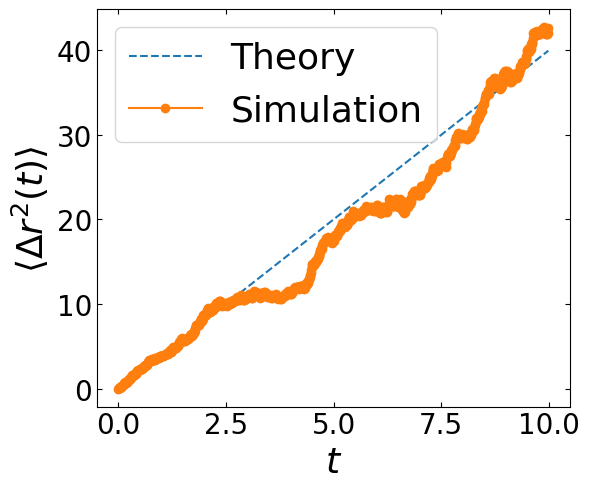

In [12]:
plt.figure(figsize=(6,5))
D = kBT / gamma
plt.plot(times, 4*D*np.array(times), '--', label='Theory')
plt.plot(times, msd, 'o-', label='Simulation')
plt.xlabel(r'$t$')
plt.ylabel(r'$\langle \Delta r^2(t) \rangle$')
plt.legend()
plt.tight_layout()
plt.show()

# B

In [13]:
# Simulation parameters
N = 50

sigma = 1.0
L = 10.0*sigma
rho = N/(L**2) # 2D

kappa = 1.0
r_cut = 6.0 / kappa

gamma = 1.0 # gamma=xi from previously

kBT = 1.0
V_0 = 2.5
U_0 = V_0 / kBT

F_D = 0 * kBT / sigma

tau = gamma * sigma**2 / V_0 # Time unit for everything
dt = 1e-4 * tau
t_equil = 10.0 * tau
t_prod = 10.0 * tau
# t_sim = t_equil + t_prod

n_steps_equil = int(t_equil / dt)
n_steps_prod = int(t_prod / dt)

In [14]:
# Minimum image convention
@njit(fastmath=True)
def min_image(dx, L):
    return dx - L * np.round(dx / L)

# Might want to smoothe the cutoff later
@njit(fastmath=True)
def V_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma/r * np.exp( -kappa*(r-sigma) )
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Quotient rule derivative; double-check at some point
@njit(fastmath=True)
def F_Yuk(r):
    if r >= r_cut or r < 1e-8:
        return 0.0
    return U_0 * np.exp(-kappa * (r - sigma)) * (kappa / r + 1.0 / (r * r))

# Intialize particles on a 2D grid, deleting some randomly if N isn't a square number
def init_grid(L, N):
    # Find smallest integer grid size n such that n^2 >= N
    n = int(np.ceil(np.sqrt(N)))

    # Build n×n grid
    coords = np.linspace(0.5*sigma, L - 0.5*sigma, n)
    X, Y= np.meshgrid(coords, coords, indexing='ij')
    pts = np.column_stack([X.ravel(), Y.ravel()])

    # Randomly choose exactly N points, implicitly deleting the rest by replace=False
    idx = np.random.choice(len(pts), N, replace=False)
    return pts[idx]

# Compute the forces using the Yukawa interaction AND the external driving
@njit(fastmath=True)
def compute_forces(pos):
    forces = np.zeros((N, 2))

    for i in range(N):
        xi, yi = pos[i]

        for j in range(i + 1, N): # <-- Only compute j > i to utilize the symmetry
            dx = min_image(xi - pos[j, 0], L)
            dy = min_image(yi - pos[j, 1], L)
            r = np.sqrt(dx*dx + dy*dy)

            F_mag = F_Yuk(r) # Magnitude of the force

            fx = F_mag * dx / r
            fy = F_mag * dy / r

            # Apply Newton's third law / symmetry of the force matrix:
            forces[i, 0] += fx
            forces[i, 1] += fy

            forces[j, 0] -= fx
            forces[j, 1] -= fy
            
    return forces

# Brownian Dynamics integration step
@njit(fastmath=True)
def bd_step_equil(pos):
    F_matrix = compute_forces(pos)
    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    for i in range(N):
        pos[i,0] -= L * np.floor(pos[i,0] / L) # Apply periodic boundary conditions
        pos[i,1] -= L * np.floor(pos[i,1] / L)

    return pos

# Brownian Dynamics integration step with species
@njit(fastmath=True)
def bd_step_drive(pos, species):
    F_matrix = compute_forces(pos)
    F_matrix[:,0] += species * F_D # external driving force

    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    for i in range(N):
        pos[i,0] -= L * np.floor(pos[i,0] / L) # Apply periodic boundary conditions
        pos[i,1] -= L * np.floor(pos[i,1] / L)

    return pos

# g(r) computation
@njit
def compute_gr(pos, r_max, dr):
    n_bins = int(r_max / dr)
    hist = np.zeros(n_bins)

    for i in range(N):
        xi, yi = pos[i]
        for j in range(i+1, N):
            dx = min_image(xi - pos[j,0], L)
            dy = min_image(yi - pos[j,1], L)
            r = np.sqrt(dx*dx + dy*dy)

            if r < r_max:
                bin_idx = int(r / dr)
                hist[bin_idx] += 2.0

    return hist

In [15]:
# Main simulation
print("Running Brownian Dynamics simulation...")
pos = init_grid(L, N)

# g(r)
r_max = L / 2
dr = 0.05 * sigma
n_bins = int(r_max / dr)
g_hist = np.zeros(n_bins)
n_samples = 0

n_steps = n_steps_equil+n_steps_prod

for step in range(n_steps):
        pos = bd_step_equil(pos)

        if step % (n_steps // 5) == 0:
                print(f"Progress: {100 * step / n_steps:.0f}%")

        if step % 100 == 0:
                g_hist += compute_gr(pos, r_max, dr)
                n_samples += 1

print("Simulation finished.")

# Normalize g(r)
r = (np.arange(n_bins) + 0.5) * dr
area = 2 * np.pi * r * dr
norm = n_samples * N * rho * area
g_r = g_hist / norm

Running Brownian Dynamics simulation...
Progress: 0%
Progress: 20%
Progress: 40%
Progress: 60%
Progress: 80%
Progress: 100%
Simulation finished.


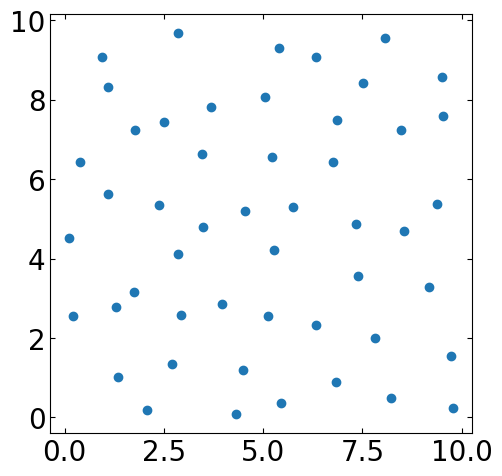

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(pos[:, 0], pos[:, 1])
ax.set_aspect('equal')
fig.tight_layout()

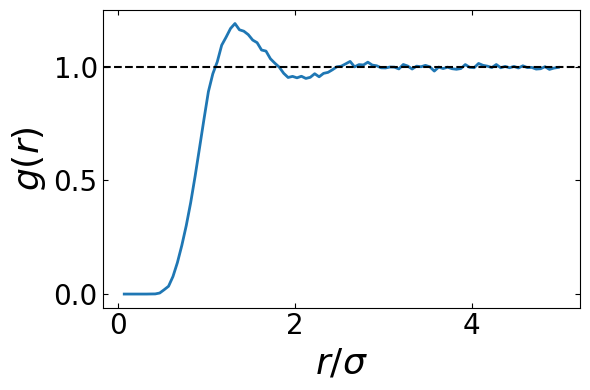

In [17]:
# Plot g(r)
plt.figure(figsize=(6,4))
plt.plot(r[1:], g_r[1:], lw=2)
plt.axhline(1.0, color="k", ls="--")
plt.xlabel(r"$r/\sigma$")
plt.ylabel(r"$g(r)$")
plt.tight_layout()
plt.show()

# C

In [3]:
# Simulation parameters
rho = 1.0
N = 200
sigma = 1.0
L = np.sqrt(N / rho)

kappa = 4.0
r_cut = 6.0 / kappa

gamma = 1.0 # gamma=xi from previously

kBT = 1.0
V_0 = 2.5
U_0 = V_0 / kBT

F_D = 150 * kBT / sigma

tau = gamma * sigma**2 / V_0 # Time unit for everything
dt = 1e-4 * tau
t_equil = 10.0 * tau
t_prod = 10.0 * tau
# t_sim = t_equil + t_prod

n_steps_equil = int(t_equil / dt)
n_steps_prod = int(t_prod / dt)

In [4]:
# Minimum image convention
@njit(fastmath=True)
def min_image(dx, L):
    return dx - L * np.round(dx / L)

# Might want to smoothe the cutoff later
@njit(fastmath=True)
def V_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma/r * np.exp( -kappa*(r-sigma) )
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Quotient rule derivative; double-check at some point
@njit(fastmath=True)
def F_Yuk(r):
    if r < 1e-8 or r > r_cut:
        return 0.0
    return V_0 * sigma * np.exp(-kappa * (r - sigma)) * (kappa * r + 1) / r**2

# Intialize particles on a 2D grid, deleting some randomly if N isn't a square number
def init_grid(L, N):
    # Find smallest integer grid size n such that n^2 >= N
    n = int(np.ceil(np.sqrt(N)))

    # Build n×n grid
    coords = np.linspace(0.5*sigma, L - 0.5*sigma, n)
    X, Y= np.meshgrid(coords, coords, indexing='ij')
    pts = np.column_stack([X.ravel(), Y.ravel()])

    # Randomly choose exactly N points, implicitly deleting the rest by replace=False
    idx = np.random.choice(len(pts), N, replace=False)
    return pts[idx]

# Compute the forces using the Yukawa interaction AND the external driving
@njit(fastmath=True)
def compute_forces(pos):
    forces = np.zeros((N, 2))

    for i in range(N):
        xi, yi = pos[i]

        for j in range(i + 1, N): # <-- Only compute j > i to utilize the symmetry
            dx = min_image(xi - pos[j, 0], L)
            dy = min_image(yi - pos[j, 1], L)
            r = np.sqrt(dx*dx + dy*dy)

            F_mag = F_Yuk(r) # Magnitude of the force

            if r < r_cut:

                fx = F_mag * dx / r
                fy = F_mag * dy / r

                # Apply Newton's third law / symmetry of the force matrix:
                forces[i, 0] += fx
                forces[i, 1] += fy

                forces[j, 0] -= fx
                forces[j, 1] -= fy
            
    return forces

# Brownian Dynamics integration step
@njit(fastmath=True)
def bd_step_equil(pos):
    F_matrix = compute_forces(pos)
    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    for i in range(N):
        pos[i,0] -= L * np.floor(pos[i,0] / L) # Apply periodic boundary conditions
        pos[i,1] -= L * np.floor(pos[i,1] / L)

    return pos

# Brownian Dynamics integration step with species
@njit(fastmath=True)
def bd_step_drive(pos, species):
    F_matrix = compute_forces(pos)
    F_matrix[:,0] += species * F_D # external driving force

    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    for i in range(N):
        pos[i,0] -= L * np.floor(pos[i,0] / L) # Apply periodic boundary conditions
        pos[i,1] -= L * np.floor(pos[i,1] / L)

    return pos

# g(r) computation
@njit
def compute_gr(pos, r_max, dr):
    n_bins = int(r_max / dr)
    hist = np.zeros(n_bins)

    for i in range(N):
        xi, yi = pos[i]
        for j in range(i+1, N):
            dx = min_image(xi - pos[j,0], L)
            dy = min_image(yi - pos[j,1], L)
            r = np.sqrt(dx*dx + dy*dy)

            if r < r_max:
                bin_idx = int(r / dr)
                hist[bin_idx] += 2.0

    return hist

def write_ovito(filename, pos, species, L, step):
    N = pos.shape[0]
    with open(filename, "a") as f:
        f.write("ITEM: TIMESTEP\n")
        f.write(f"{step}\n")
        f.write("ITEM: NUMBER OF ATOMS\n")
        f.write(f"{N}\n")
        f.write("ITEM: BOX BOUNDS pp pp pp\n")
        f.write(f"0 {L}\n")
        f.write(f"0 {L}\n")
        f.write(f"0 1\n")   # fake z-dimension (OVITO needs it)
        f.write("ITEM: ATOMS id type x y z\n")

        for i in range(N):
            atom_id = i + 1
            atom_type = 1 if species[i] == 1 else 2
            x, y = pos[i]
            f.write(f"{atom_id} {atom_type} {x} {y} 0.0\n")


In [5]:
pos = init_grid(L, N)

# Equilibration
for step in range(n_steps_equil):
    pos = bd_step_equil(pos)

    if step % (n_steps_equil // 5) == 0:
        print(f"Progress: {100 * step / n_steps_equil:.0f}%")

# Plot positions, potentially w/o the equilibration above to check that everything works:
# fig, ax = plt.subplots(figsize=(5, 5))

# ax.scatter(pos[:, 0], pos[:, 1])
# ax.set_aspect('equal')
# fig.tight_layout()

Progress: 0%
Progress: 20%
Progress: 40%
Progress: 60%
Progress: 80%
Progress: 100%


In [6]:
# Main simulation
print("Running Brownian Dynamics simulation...")

# Ovito
dumpfile = "lanes.dump"
open(dumpfile, "w").close()   # clear file

# Species labels f_i = ±1
species = np.ones(N)
species[:N // 2] = -1
np.random.shuffle(species)

vx_A = []
vx_B = []

for step in range(n_steps_prod):
        pos_old = pos.copy()
        pos = bd_step_drive(pos, species)

        dx = pos[:,0] - pos_old[:,0]
        dx = min_image(dx, L)
        vx = dx/dt

        vx_A.append(np.mean(vx[species == 1]))
        vx_B.append(np.mean(vx[species == -1]))

        if step % (n_steps_prod // 5) == 0:
                print(f"Progress: {100 * step / n_steps_prod:.0f}%")

        if step % 10 == 0:
                write_ovito(dumpfile, pos, species, L, step)

print("Simulation finished.")

vA = np.mean(vx_A)
vB = np.mean(vx_B)

print("Measured ⟨v_x⟩ (A):", vA)
print("Measured ⟨v_x⟩ (B):", vB)
print("Theory F_D/γ:", F_D / gamma)

Running Brownian Dynamics simulation...
Progress: 0%
Progress: 20%
Progress: 40%
Progress: 60%
Progress: 80%
Progress: 100%
Simulation finished.
Measured ⟨v_x⟩ (A): 148.72916397626093
Measured ⟨v_x⟩ (B): -148.68177247699055
Theory F_D/γ: 150.0


In [7]:
df = pd.DataFrame(dict(L=pos[:,0], R=pos[:,1], label=species))
groups = df.groupby('label')

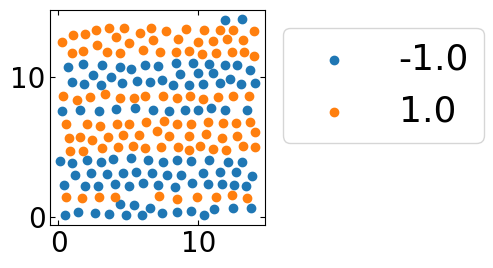

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))

for particle, group in groups:
    ax.scatter(group.L, group.R, label=particle)
    ax.legend(bbox_to_anchor=(1, 1))
    ax.set_aspect('equal')
fig.tight_layout()

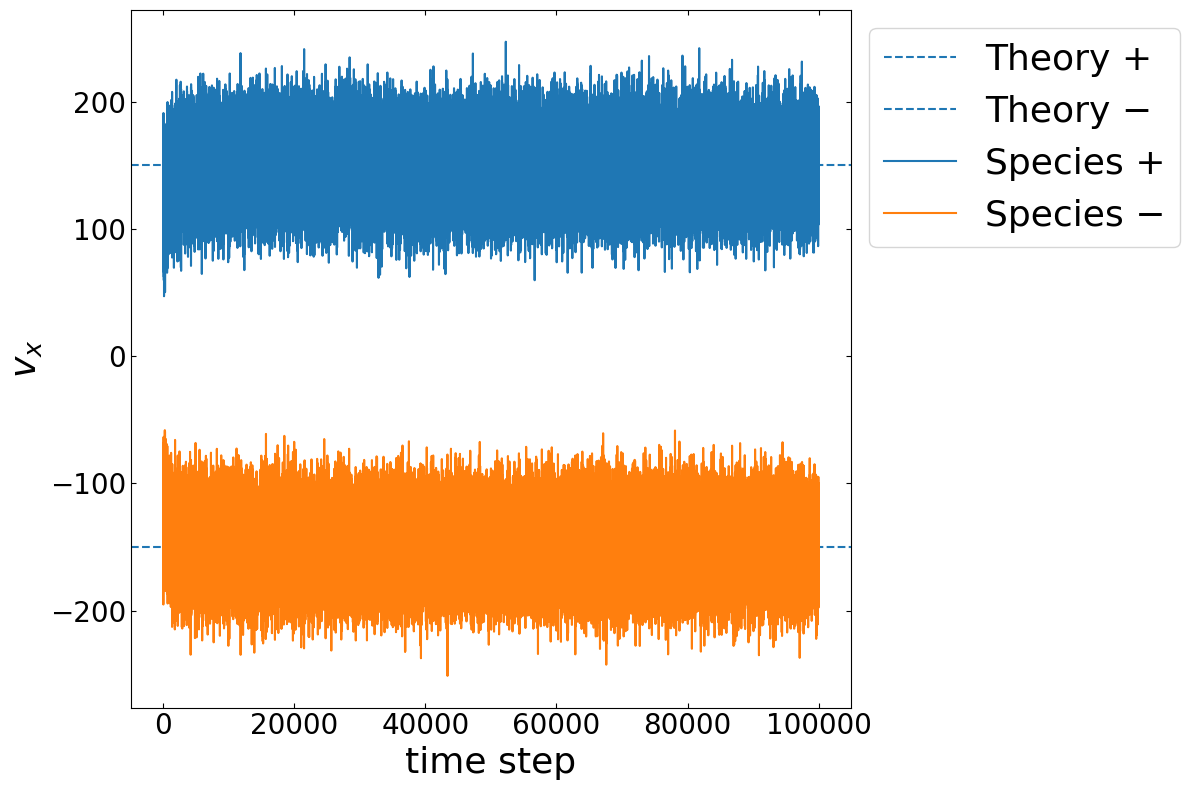

In [9]:
plt.figure(figsize=(12,8))
plt.axhline(F_D/gamma, ls="--", label="Theory +")
plt.axhline(-F_D/gamma, ls="--", label="Theory −")
plt.plot(vx_A, label="Species +")
plt.plot(vx_B, label="Species −")
plt.xlabel("time step")
plt.ylabel(r"$v_x$")
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()